# Gaussian Distributions: Visual Learning Notebook



## Learning objectives
- Interpret the mean and variance of a one-dimensional Gaussian.
- Understand marginalization and conditioning in a joint Gaussian.
- See why affine-Gaussian models remain Gaussian.
- Perform a scalar Bayesian update using prior precision and likelihood precision.
- Visualize products of Gaussians and truncated Gaussians.

The central visual convention is: **red = joint or original density, blue = conditional/marginal, orange = affine model, green = truncation**.

## 0. Setup

We use NumPy for numerical calculations, SciPy for Gaussian densities and CDFs, Matplotlib for plots, and `ipywidgets` for sliders.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from IPython.display import display, Markdown
!pip install numpy scipy matplotlib ipywidgets
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.style.use('seaborn-v0_8-whitegrid')
RNG = np.random.default_rng(7)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.6 MB/s eta 0:00:00


## 1. The one-dimensional Gaussian

A scalar Gaussian with mean `μ` and variance `σ²` has density

$$
p(x) = \mathcal{N}(x;\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].
$$

The mean moves the center of the curve. The standard deviation changes its width: larger `σ` means greater uncertainty and a flatter curve.

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2007/3389344529.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.fill_between(x, y, where=(x >= mu-sigma) & (x <= mu+sigma), alpha=.25, color='royalblue', label='$\mu\pm\sigma$')


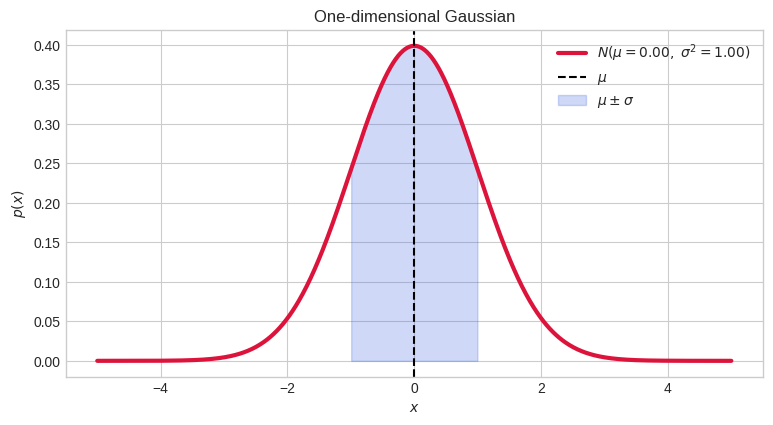

In [ ]:
def gaussian1d(x, mu=0.0, sigma=1.0):
    return norm.pdf(x, loc=mu, scale=sigma)

def plot_1d(mu=0.0, sigma=1.0):
    x = np.linspace(-5, 5, 800)
    y = gaussian1d(x, mu, sigma)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(x, y, color='crimson', lw=3, label=rf'$N(\mu={mu:.2f},\;\sigma^2={sigma**2:.2f})$')
    ax.axvline(mu, color='black', ls='--', label=r'$\mu$')
    ax.fill_between(x, y, where=(x >= mu-sigma) & (x <= mu+sigma), alpha=.25, color='royalblue', label='$\mu\pm\sigma$')
    ax.set(xlabel='$x$', ylabel='$p(x)$', title='One-dimensional Gaussian')
    ax.legend()
    plt.show()

plot_1d()

In [ ]:
if WIDGETS_AVAILABLE:
    interact(plot_1d,
             mu=widgets.FloatSlider(min=-2, max=2, step=.1, value=0, description='μ'),
             sigma=widgets.FloatSlider(min=.2, max=2.5, step=.1, value=1, description='σ'))

interactive(children=(FloatSlider(value=0.0, description='μ', max=2.0, min=-2.0), FloatSlider(value=1.0, descr…

### Checkpoint

What happens to the peak height when `σ` increases? The total area remains one because the curve spreads out while preserving total probability.

## 2. A partitioned multivariate Gaussian

Stack two variables into a vector:

$$
\begin{bmatrix}x\\y\end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix}\mu_x\\\mu_y\end{bmatrix},\begin{bmatrix}\Sigma_{xx}&\Sigma_{xy}\\\Sigma_{yx}&\Sigma_{yy}\end{bmatrix}\right).
$$

For the simple correlated example, `μ = [0, 0]` and

$$\Sigma = \begin{bmatrix}1&\rho\\\rho&1\end{bmatrix}.$$

The parameter `ρ` controls the tilt of the elliptical contours.

## 3. Marginalization: remove a variable

The marginal of `x` is obtained by integrating out `y`:

$$p(x)=\int p(x,y)\,dy = \mathcal{N}(x;\mu_x,\Sigma_{xx}).$$

The important visual message is that the marginal is not a slice at one value of `y`; it combines probability over **all** values of `y`.

## 4. Conditioning: fix a variable

The conditional distribution is

$$p(x\mid y)=\mathcal{N}(x;\mu_{x\mid y},\Sigma_{x\mid y}),$$

with

$$\mu_{x\mid y}=\mu_x+\Sigma_{xy}\Sigma_{yy}^{-1}(y-\mu_y),$$
$$\Sigma_{x\mid y}=\Sigma_{xx}-\Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}.$$

For the correlated standard Gaussian, this becomes

$$x\mid y \sim \mathcal{N}(\rho y,1-\rho^2).$$

Thus conditioning gives a linear prediction plus residual Gaussian uncertainty.

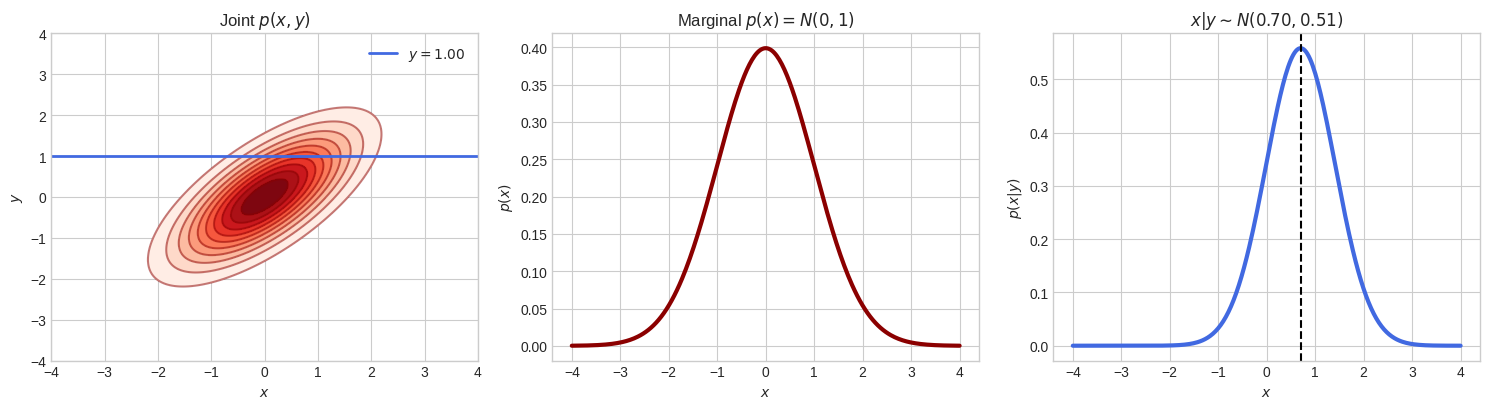

In [ ]:
def gaussian2d(X, Y, mu, Sigma):
    points = np.dstack((X, Y))
    return multivariate_normal(mean=np.asarray(mu), cov=np.asarray(Sigma)).pdf(points)

def plot_bivariate(rho=0.7, y_value=1.0):
    mu = np.array([0., 0.])
    Sigma = np.array([[1., rho], [rho, 1.]])
    x = np.linspace(-4, 4, 300)
    y = np.linspace(-4, 4, 300)
    X, Y = np.meshgrid(x, y)
    Z = gaussian2d(X, Y, mu, Sigma)
    conditional_mean = rho * y_value
    conditional_var = 1 - rho**2

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    levels = np.linspace(Z.min(), Z.max(), 12)[1:]
    axes[0].contourf(X, Y, Z, levels=levels, cmap='Reds')
    axes[0].contour(X, Y, Z, levels=levels, colors='darkred', alpha=.5)
    axes[0].axhline(y_value, color='royalblue', lw=2, label=rf'$y={y_value:.2f}$')
    axes[0].set(xlabel='$x$', ylabel='$y$', title='Joint $p(x,y)$')
    axes[0].legend()
    axes[1].plot(x, norm.pdf(x), color='darkred', lw=3)
    axes[1].set(xlabel='$x$', ylabel='$p(x)$', title='Marginal $p(x)=N(0,1)$')
    axes[2].plot(x, norm.pdf(x, conditional_mean, np.sqrt(conditional_var)), color='royalblue', lw=3)
    axes[2].axvline(conditional_mean, color='black', ls='--')
    axes[2].set(xlabel='$x$', ylabel='$p(x|y)$', title=rf'$x|y \sim N({conditional_mean:.2f},{conditional_var:.2f})$')
    plt.tight_layout()
    plt.show()

plot_bivariate()

In [ ]:
if WIDGETS_AVAILABLE:
    interact(plot_bivariate,
             rho=widgets.FloatSlider(min=-.95, max=.95, step=.05, value=.7, description='ρ'),
             y_value=widgets.FloatSlider(min=-2.5, max=2.5, step=.1, value=1, description='fixed y'))

interactive(children=(FloatSlider(value=0.7, description='ρ', max=0.95, min=-0.95, step=0.05), FloatSlider(val…

## 5. Affine-Gaussian models

Suppose

$$x\sim\mathcal{N}(\mu_x,\Sigma_x), \qquad y\mid x\sim\mathcal{N}(Ax+b,\Sigma_{y\mid x}).$$

Then the predictive distribution is Gaussian:

$$y\sim\mathcal{N}(A\mu_x+b,\;\Sigma_{y\mid x}+A\Sigma_xA^\top).$$

The predictive variance has two sources: observation noise and uncertainty propagated from `x`.

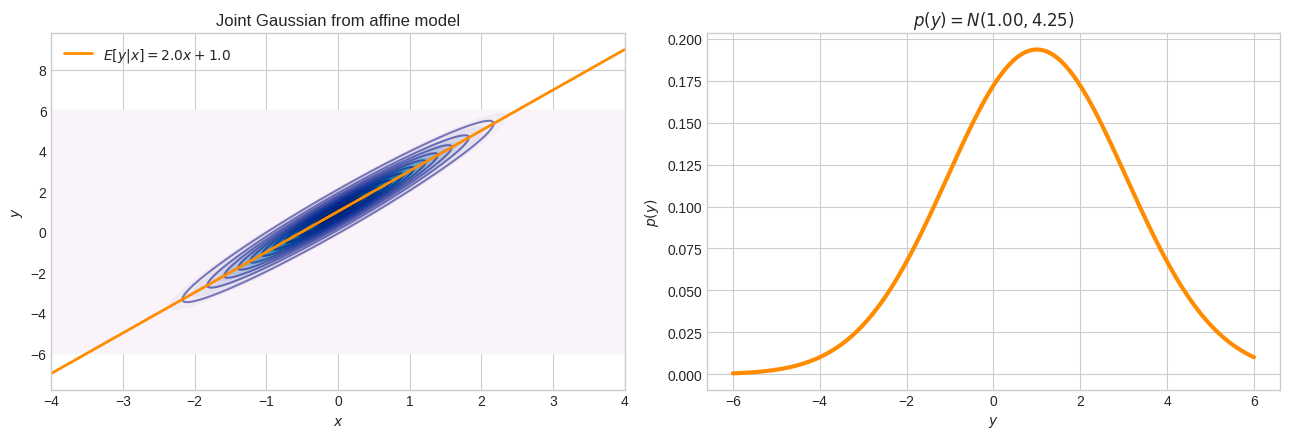

In [ ]:
def affine_gaussian(mu_x, Sigma_x, A, b, Sigma_noise):
    mu_x = np.atleast_1d(mu_x)
    A = np.atleast_2d(A)
    b = np.atleast_1d(b)
    Sigma_x = np.atleast_2d(Sigma_x)
    Sigma_noise = np.atleast_2d(Sigma_noise)
    mu_y = A @ mu_x + b
    Sigma_y = Sigma_noise + A @ Sigma_x @ A.T
    joint_mean = np.concatenate([mu_x, mu_y])
    joint_cov = np.block([[Sigma_x, Sigma_x @ A.T], [A @ Sigma_x, Sigma_y]])
    return joint_mean, joint_cov, mu_y, Sigma_y

def plot_affine(A=2.0, b=1.0, noise_sigma=.5):
    joint_mean, joint_cov, mu_y, Sigma_y = affine_gaussian(
        np.array([0.]), np.array([[1.]]), np.array([[A]]), np.array([b]), np.array([[noise_sigma**2]]))
    x = np.linspace(-4, 4, 250)
    y = np.linspace(-6, 6, 250)
    X, Y = np.meshgrid(x, y)
    Z = gaussian2d(X, Y, joint_mean, joint_cov)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].contourf(X, Y, Z, levels=18, cmap='PuBu')
    axes[0].contour(X, Y, Z, levels=10, colors='navy', alpha=.5)
    axes[0].plot(x, A*x+b, color='darkorange', lw=2, label=rf'$E[y|x]={A:.1f}x+{b:.1f}$')
    axes[0].set(xlabel='$x$', ylabel='$y$', title='Joint Gaussian from affine model')
    axes[0].legend()
    axes[1].plot(y, norm.pdf(y, mu_y.item(), np.sqrt(Sigma_y.item())), color='darkorange', lw=3)
    axes[1].set(xlabel='$y$', ylabel='$p(y)$', title=rf'$p(y)=N({mu_y.item():.2f},{Sigma_y.item():.2f})$')
    plt.tight_layout()
    plt.show()

plot_affine()

## 6. Bayesian Gaussian update

For the scalar model

$$x\sim\mathcal{N}(\mu_0,\sigma_0^2),\qquad y\mid x\sim\mathcal{N}(x,\sigma_n^2),$$

the posterior is

$$\sigma_1^2=\left(\frac{1}{\sigma_0^2}+\frac{1}{\sigma_n^2}\right)^{-1},$$
$$\mu_1=\sigma_1^2\left(\frac{\mu_0}{\sigma_0^2}+\frac{y}{\sigma_n^2}\right).$$

This is a precision-weighted average: the more precise source receives more weight.

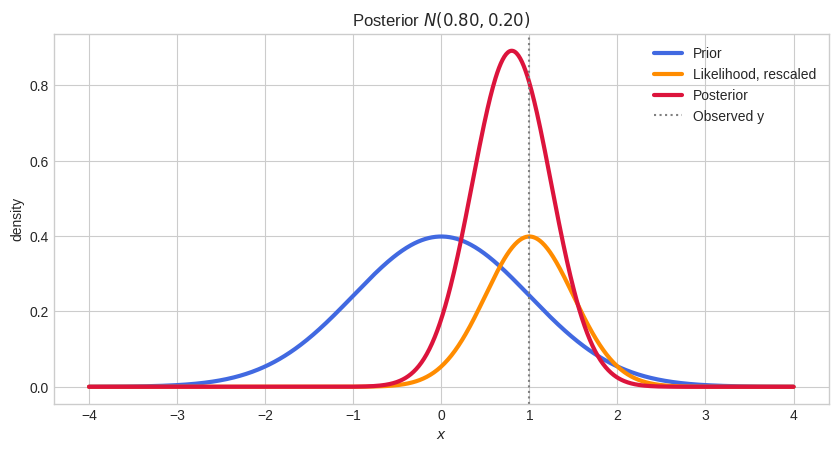

In [ ]:
def posterior_scalar(prior_mu=0., prior_sigma=1., observation=1., noise_sigma=.5):
    prior_precision = 1 / prior_sigma**2
    noise_precision = 1 / noise_sigma**2
    post_var = 1 / (prior_precision + noise_precision)
    post_mu = post_var * (prior_precision * prior_mu + noise_precision * observation)
    return post_mu, post_var

def plot_posterior(prior_mu=0., prior_sigma=1., observation=1., noise_sigma=.5):
    post_mu, post_var = posterior_scalar(prior_mu, prior_sigma, observation, noise_sigma)
    x = np.linspace(-4, 4, 800)
    prior = norm.pdf(x, prior_mu, prior_sigma)
    likelihood = norm.pdf(observation, x, noise_sigma)
    likelihood = likelihood / likelihood.max() * prior.max()
    posterior = norm.pdf(x, post_mu, np.sqrt(post_var))
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(x, prior, lw=3, label='Prior', color='royalblue')
    ax.plot(x, likelihood, lw=3, label='Likelihood, rescaled', color='darkorange')
    ax.plot(x, posterior, lw=3, label='Posterior', color='crimson')
    ax.axvline(observation, color='gray', ls=':', label='Observed y')
    ax.set(xlabel='$x$', ylabel='density', title=rf'Posterior $N({post_mu:.2f},{post_var:.2f})$')
    ax.legend()
    plt.show()

plot_posterior()

In [ ]:
if WIDGETS_AVAILABLE:
    interact(plot_posterior,
             prior_mu=widgets.FloatSlider(min=-2, max=2, step=.1, value=0, description='prior μ'),
             prior_sigma=widgets.FloatSlider(min=.2, max=2, step=.1, value=1, description='prior σ'),
             observation=widgets.FloatSlider(min=-3, max=3, step=.1, value=1, description='observed y'),
             noise_sigma=widgets.FloatSlider(min=.1, max=2, step=.1, value=.5, description='noise σ'))

interactive(children=(FloatSlider(value=0.0, description='prior μ', max=2.0, min=-2.0), FloatSlider(value=1.0,…

## 7. Product of two Gaussians

The product of two Gaussian-shaped functions is proportional to another Gaussian:

$$\sigma^2=\left(\frac{1}{\sigma_1^2}+\frac{1}{\sigma_2^2}\right)^{-1},\qquad
m=\sigma^2\left(\frac{m_1}{\sigma_1^2}+\frac{m_2}{\sigma_2^2}\right).$$

The product is narrower than either input when both inputs are proper Gaussian densities. This is the algebra behind Gaussian Bayesian updating.

/tmp/ipykernel_2007/2968196955.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  product /= np.trapz(product, x)


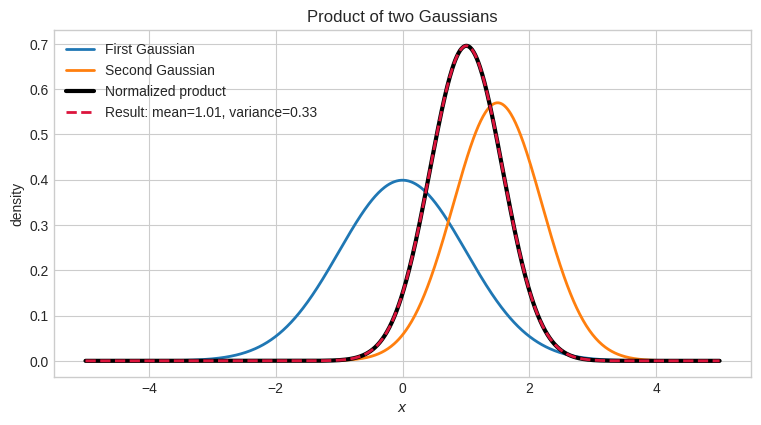

In [ ]:
def plot_product(m1=0., s1=1., m2=1.5, s2=.7):
    x = np.linspace(-5, 5, 800)
    p1, p2 = norm.pdf(x, m1, s1), norm.pdf(x, m2, s2)
    var = 1 / (1/s1**2 + 1/s2**2)
    mean = var * (m1/s1**2 + m2/s2**2)
    product = p1*p2
    product /= np.trapz(product, x)
    result = norm.pdf(x, mean, np.sqrt(var))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(x, p1, label='First Gaussian', lw=2)
    ax.plot(x, p2, label='Second Gaussian', lw=2)
    ax.plot(x, product, label='Normalized product', color='black', lw=3)
    ax.plot(x, result, '--', label=rf'Result: mean={mean:.2f}, variance={var:.2f}', color='crimson', lw=2)
    ax.set(xlabel='$x$', ylabel='density', title='Product of two Gaussians')
    ax.legend()
    plt.show()

plot_product()

## 8. Truncated Gaussian

If only values in `(a,b)` are physically possible, renormalize the Gaussian over that interval:

$$f(x)=\frac{\mathcal{N}(x;\mu,\sigma^2)}{F(b;\mu,\sigma^2)-F(a;\mu,\sigma^2)},\qquad a<x<b.$$

The denominator is the probability mass retained after imposing the constraint.

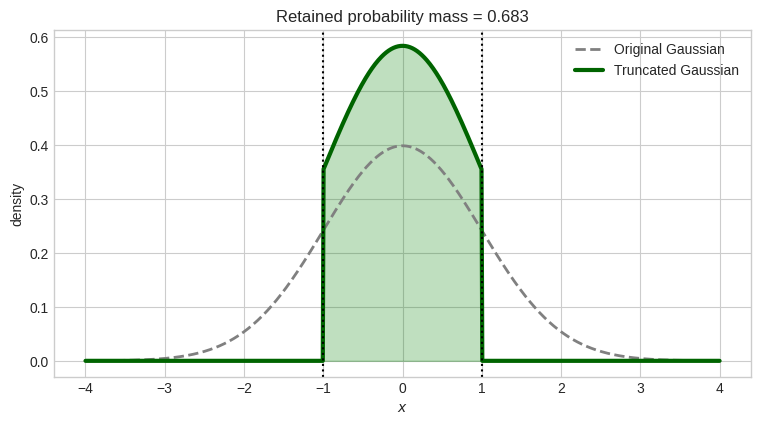

In [ ]:
def plot_truncated(mu=0., sigma=1., lower=-1., upper=1.):
    if lower >= upper:
        print('Please choose lower < upper.')
        return
    x = np.linspace(mu-4*sigma, mu+4*sigma, 800)
    base = norm.pdf(x, mu, sigma)
    retained_mass = norm.cdf(upper, mu, sigma) - norm.cdf(lower, mu, sigma)
    truncated = np.where((x >= lower) & (x <= upper), base/retained_mass, 0.)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(x, base, '--', color='gray', lw=2, label='Original Gaussian')
    ax.plot(x, truncated, color='darkgreen', lw=3, label='Truncated Gaussian')
    ax.axvline(lower, color='black', ls=':')
    ax.axvline(upper, color='black', ls=':')
    ax.fill_between(x, truncated, where=(x >= lower) & (x <= upper), alpha=.25, color='green')
    ax.set(xlabel='$x$', ylabel='density', title=rf'Retained probability mass = {retained_mass:.3f}')
    ax.legend()
    plt.show()

plot_truncated()

In [ ]:
if WIDGETS_AVAILABLE:
    interact(plot_truncated,
             mu=widgets.FloatSlider(min=-2, max=2, step=.1, value=0, description='μ'),
             sigma=widgets.FloatSlider(min=.2, max=2, step=.1, value=1, description='σ'),
             lower=widgets.FloatSlider(min=-4, max=1, step=.1, value=-1, description='lower'),
             upper=widgets.FloatSlider(min=-1, max=4, step=.1, value=1, description='upper'))

interactive(children=(FloatSlider(value=0.0, description='μ', max=2.0, min=-2.0), FloatSlider(value=1.0, descr…

## 9. Concept map

```text
              Joint Gaussian p(x,y)
                 /           \
   marginalize /               \ condition
              v                 v
          p(x)              p(x|y)
              \                 /
               \               /
                v             v
                 p(y)  <--> posterior p(x|y)
                    affine-Gaussian model
```

The same structure appears repeatedly: start with a joint Gaussian, then obtain marginals, conditionals, predictive distributions, and posteriors by applying Gaussian identities.

## 10. Student exercises

1. Set `ρ = 0`. What happens to the conditional mean and variance?
2. Set `ρ = 0.9`. How much smaller is the conditional variance than the marginal variance?
3. In the affine model, increase the noise standard deviation. How does the predictive distribution change?
4. In the Bayesian update, make the prior standard deviation very small. Does the posterior stay close to the prior mean or the observation? Explain using precision.
5. Change the truncation limits so that only a small amount of probability mass remains. Why does the truncated density become taller?
6. Numerically verify that a normalized density integrates to approximately one using `np.trapz`.

### Key takeaways
- Marginalization integrates out uncertainty in the removed variable.
- Conditioning fixes an observed variable and reduces uncertainty.
- Affine transformations of Gaussian variables remain Gaussian.
- Gaussian prior times Gaussian likelihood produces a Gaussian posterior.
- Truncation preserves the allowed part and renormalizes it.

## Acknowledgement of AI use

This Jupyter notebook was prepared using a large language model (ChatGPT by OpenAI or Claude by Anthropic). The code, explanations, and examples were reviewed and checked by the instructor.